<a href="https://colab.research.google.com/github/hrachubi/ML-in-Python/blob/main/Klasyfikacja_danych_baza_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import ensemble, preprocessing, tree
from sklearn.metrics import auc, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold
from yellowbrick.classifier import ConfusionMatrix, ROCAUC
from yellowbrick.model_selection import LearningCurve

In [2]:
import copy
import seaborn as sns
df_seaborn = sns.load_dataset('titanic')

In [3]:
df = df_seaborn.copy()
orig_df = df.copy() # Make a separate copy for orig_df if it's meant to be truly original
df = df.drop(columns=['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town'])

In [4]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
alone,bool


In [5]:
import sys

# Install pandas-profiling if it's not already installed
!{sys.executable} -m pip install -q pandas-profiling

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [6]:
import sys

# Install ydata-profiling (formerly pandas-profiling)
!{sys.executable} -m pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.3 MB/s eta 0:00:00


### Sprawdzanie opcji zaimportowanego modułu

Aby sprawdzić dostępne opcje i funkcje zaimportowanej biblioteki lub modułu, możesz użyć wbudowanych funkcji Pythona:

1.  **`help()`**: Daje szczegółową dokumentację obiektu (modułu, funkcji, klasy).
    ```python
    help(pandas_profiling.ProfileReport)
    ```

2.  **`dir()`**: Zwraca listę wszystkich atrybutów (metod i zmiennych) obiektu.
    ```python
    dir(pandas_profiling)
    ```

Teraz, gdy `pandas_profiling` jest zainstalowane, możesz uruchomić raport profilowania.

In [7]:
import ydata_profiling
ydata_profiling.ProfileReport(df)

/tmp/ipykernel_724/558275835.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  import ydata_profiling


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


 11%|█         | 1/9 [00:00<00:02,  3.10it/s]/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

100%|██████████| 9/9 [00:00<00:00, 10.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
alone,0


In [9]:
mask=df.isnull().any(axis=1)
mask.head()

,0
0,False
1,False
2,False
3,False
4,False


In [10]:
df[mask].age.head()

,age
5,NaN
17,NaN
19,NaN
26,NaN
28,NaN


In [11]:
df = pd.get_dummies(df, drop_first=True)

In [12]:
y = df.survived
X = df.drop(columns='survived')

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
num_cols = ["pclass", "age", "sibsp", "parch", "fare"]
cat_cols = ["sex_male", "embarked_Q", "embarked_S"]

In [15]:
num_cols = ["pclass", "age", "sibsp", "parch", "fare"]
cat_cols = ["sex_male", "embarked_Q", "embarked_S"]

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(random_state=42)
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])

X_test[num_cols] = imputer.transform(X_test[num_cols])

In [16]:
from sklearn.impute import SimpleImputer

### Imputacja brakujących wartości w kolumnach kategorycznych

Używamy `SimpleImputer` ze strategią `most_frequent` (najczęściej występująca wartość) do uzupełnienia brakujących danych w kolumnach kategorycznych. Imputer jest dopasowywany tylko do zestawu treningowego (`X_train`), a następnie używany do transformacji zarówno `X_train`, jak i `X_test`, aby zapobiec wyciekowi danych.

In [17]:
# Inicjalizacja SimpleImputer dla danych kategorycznych ze strategią 'most_frequent'
cat_imputer = SimpleImputer(strategy='most_frequent')

# Dopasowanie imputera do danych treningowych i transformacja X_train
# Konwersja kolumn boolean na int bezpośrednio przed fit_transform
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols].astype(int))

# Transformacja X_test za pomocą dopasowanego imputera (BEZ ponownego dopasowania)
# Konwersja kolumn boolean na int bezpośrednio przed transform
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols].astype(int))

print("Brakujące wartości w X_train po imputacji kategorycznej:")
print(X_train[cat_cols].isnull().sum())

print("\nBrakujące wartości w X_test po imputacji kategorycznej:")
print(X_test[cat_cols].isnull().sum())

Brakujące wartości w X_train po imputacji kategorycznej:
sex_male      0
embarked_Q    0
embarked_S    0
dtype: int64

Brakujące wartości w X_test po imputacji kategorycznej:
sex_male      0
embarked_Q    0
embarked_S    0
dtype: int64


In [18]:
from sklearn.preprocessing import StandardScaler

# Inicjalizacja StandardScaler
scaler = StandardScaler()

# Dopasowanie scaler'a do danych treningowych i transformacja X_train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Transformacja X_test za pomocą dopasowanego scaler'a
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Kolumny numeryczne w X_train po normalizacji (pierwsze 5 wierszy):")
print(X_train[num_cols].head())

print("\nKolumny numeryczne w X_test po normalizacji (pierwsze 5 wierszy):")
print(X_test[num_cols].head())

Kolumny numeryczne w X_train po normalizacji (pierwsze 5 wierszy):
       pclass       age     sibsp     parch      fare
445 -1.637881 -1.804353 -0.474161  1.998853  0.980998
650  0.803267 -0.081525 -0.474161 -0.479327 -0.469634
172  0.803267 -2.022872  0.348687  0.759763 -0.406136
450 -0.417307  0.526519  0.348687  1.998853 -0.080232
314 -0.417307  1.036397  0.348687  0.759763 -0.109651

Kolumny numeryczne w X_test po normalizacji (pierwsze 5 wierszy):
       pclass       age     sibsp     parch      fare
709  0.803267 -0.444559  0.348687  0.759763 -0.325478
439 -0.417307  0.162320 -0.474161 -0.479327 -0.418557
840  0.803267 -0.638917 -0.474161 -0.479327 -0.469061
720 -0.417307 -1.658673 -0.474161  0.759763  0.022737
39   0.803267 -1.075955  0.348687 -0.479327 -0.404010


github test


In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Inicjalizacja DummyClassifier ze strategią 'stratified'
# Przewiduje klasy losowo, ale z zachowaniem proporcji klas z zestawu treningowego
dummy_clf_stratified = DummyClassifier(strategy='stratified', random_state=42)

# Trenowanie modelu
dummy_clf_stratified.fit(X_train, y_train)

# Przewidywania na zbiorze testowym
y_pred_dummy_stratified = dummy_clf_stratified.predict(X_test)
y_proba_dummy_stratified = dummy_clf_stratified.predict_proba(X_test)[:, 1]

# Ocena modelu
print("=== DummyClassifier (Strategia: stratified) ===")
print(f"Dokładność (Accuracy): {accuracy_score(y_test, y_pred_dummy_stratified):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_dummy_stratified):.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_dummy_stratified))

# Inicjalizacja DummyClassifier ze strategią 'most_frequent'
# Zawsze przewiduje najczęściej występującą klasę
dummy_clf_most_frequent = DummyClassifier(strategy='most_frequent', random_state=42)

# Trenowanie modelu
dummy_clf_most_frequent.fit(X_train, y_train)

# Przewidywania na zbiorze testowym
y_pred_dummy_most_frequent = dummy_clf_most_frequent.predict(X_test)

# Ocena modelu
print("\n=== DummyClassifier (Strategia: most_frequent) ===")
print(f"Dokładność (Accuracy): {accuracy_score(y_test, y_pred_dummy_most_frequent):.4f}")
# Dla 'most_frequent' ROC AUC może nie być sensowny, jeśli tylko jedna klasa jest przewidywana
# print(f"ROC AUC: {roc_auc_score(y_test, y_pred_dummy_most_frequent):.4f}") # To spowodowałoby błąd
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_dummy_most_frequent))

=== DummyClassifier (Strategia: stratified) ===
Dokładność (Accuracy): 0.4888
ROC AUC: 0.4687

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.56      0.59      0.57       157
           1       0.38      0.35      0.36       111

    accuracy                           0.49       268
   macro avg       0.47      0.47      0.47       268
weighted avg       0.48      0.49      0.49       268


=== DummyClassifier (Strategia: most_frequent) ===
Dokładność (Accuracy): 0.5858

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.59      1.00      0.74       157
           1       0.00      0.00      0.00       111

    accuracy                           0.59       268
   macro avg       0.29      0.50      0.37       268
weighted avg       0.34      0.59      0.43       268



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from sklearn.metrics import precision_score

print("\n=== Dodatkowe metryki dla DummyClassifier (Strategia: stratified) ===")
# Precision dla klasy 1 (positive class), którą chcemy przewidzieć (Survived)
precision_stratified_class_1 = precision_score(y_test, y_pred_dummy_stratified, pos_label=1, zero_division=0)
print(f"Precyzja dla klasy '1' (Survived): {precision_stratified_class_1:.4f}")

# Precyzja uśredniona ważona (uwzględnia nierównowagę klas)
precision_stratified_weighted = precision_score(y_test, y_pred_dummy_stratified, average='weighted', zero_division=0)
print(f"Precyzja uśredniona ważona: {precision_stratified_weighted:.4f}")


print("\n=== Dodatkowe metryki dla DummyClassifier (Strategia: most_frequent) ===")
# Precision dla klasy 1 (positive class) - tutaj będzie 0, co już widzieliśmy
precision_most_frequent_class_1 = precision_score(y_test, y_pred_dummy_most_frequent, pos_label=1, zero_division=0)
print(f"Precyzja dla klasy '1' (Survived): {precision_most_frequent_class_1:.4f}")

# Precyzja uśredniona ważona (uwzględnia nierównowagę klas)
precision_most_frequent_weighted = precision_score(y_test, y_pred_dummy_most_frequent, average='weighted', zero_division=0)
print(f"Precyzja uśredniona ważona: {precision_most_frequent_weighted:.4f}")


=== Dodatkowe metryki dla DummyClassifier (Strategia: stratified) ===
Precyzja dla klasy '1' (Survived): 0.3750
Precyzja uśredniona ważona: 0.4839

=== Dodatkowe metryki dla DummyClassifier (Strategia: most_frequent) ===
Precyzja dla klasy '1' (Survived): 0.0000
Precyzja uśredniona ważona: 0.3432


In [21]:
X = pd.concat([X_train, X_test])
y = pd.concat([y_train, y_test])

from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import xgboost as xgb

# Inicjalizacja klasyfikatorów
models = [LogisticRegression(),
          KNeighborsClassifier(), SVC(), DecisionTreeClassifier(),
          RandomForestClassifier(), GaussianNB(), MLPClassifier(), DummyClassifier(),
          xgb.XGBClassifier()]

for model in models:
  cls = model
  kfold = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
  cv_results = model_selection.cross_val_score(cls, X, y, cv=kfold, scoring='accuracy')
  s = model_selection.cross_val_score(cls, X, y, cv=kfold, scoring='roc_auc')

  print(f"{model.__class__.__name__}: {cv_results.mean():.4f}")
  print(f"{model.__class__.__name__:22} AUC: {s.mean():.3f} STF: {s.std():.2f}")

LogisticRegression: 0.7947
LogisticRegression     AUC: 0.849 STF: 0.05
KNeighborsClassifier: 0.7868
KNeighborsClassifier   AUC: 0.832 STF: 0.05
SVC: 0.8160
SVC                    AUC: 0.846 STF: 0.05
DecisionTreeClassifier: 0.7834
DecisionTreeClassifier AUC: 0.764 STF: 0.05
RandomForestClassifier: 0.8025
RandomForestClassifier AUC: 0.860 STF: 0.04
GaussianNB: 0.7823
GaussianNB             AUC: 0.823 STF: 0.05


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptro

MLPClassifier: 0.8070
MLPClassifier          AUC: 0.858 STF: 0.05
DummyClassifier: 0.6161
DummyClassifier        AUC: 0.500 STF: 0.00
XGBClassifier: 0.8081
XGBClassifier          AUC: 0.863 STF: 0.05


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [09:14:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


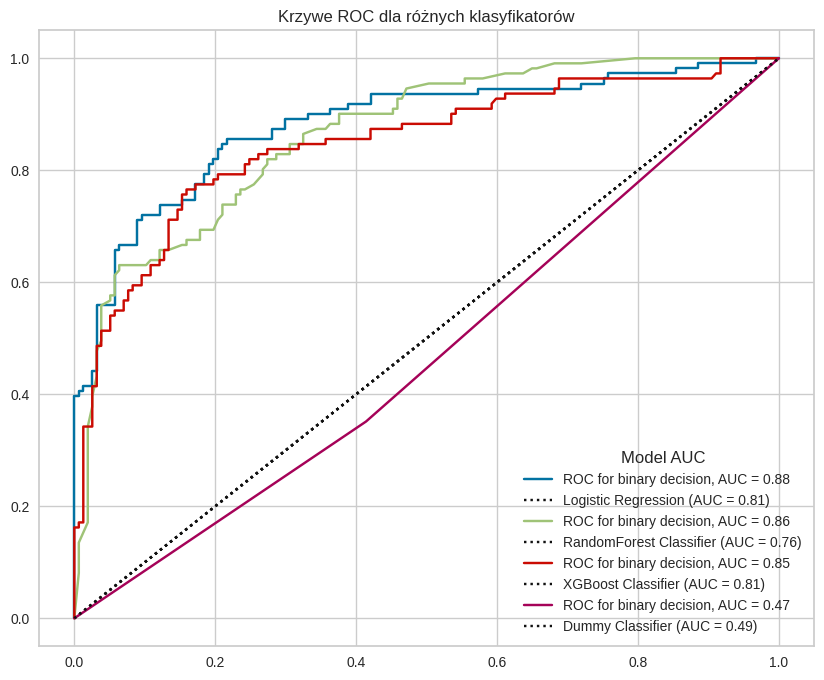

In [22]:
from yellowbrick.classifier import ROCAUC

# Wybór modeli do wizualizacji (np. najlepsze, średnie i bazowe)
selected_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "RandomForest Classifier": RandomForestClassifier(random_state=42),
    "XGBoost Classifier": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), # Dodano eval_metric
    "Dummy Classifier": DummyClassifier(strategy='stratified', random_state=42)
}

plt.figure(figsize=(10, 8))
ax = plt.gca()

for name, model in selected_models.items():
    visualizer = ROCAUC(model, classes=['Not Survived', 'Survived'], micro=False, macro=False, per_class=False, ax=ax)
    # Trening modelu na danych treningowych
    visualizer.fit(X_train, y_train)

    # Ocena modelu na danych testowych i pobranie wartości AUC
    auc_score = visualizer.score(X_test, y_test)

    # Ustawienie etykiety z wartością AUC
    visualizer.ax.lines[-1].set_label(f'{name} (AUC = {auc_score:.2f})')

ax.legend(loc='lower right', title='Model AUC')
ax.set_title('Krzywe ROC dla różnych klasyfikatorów')
plt.show()

Na powyższym wykresie widzimy krzywe ROC dla wybranych modeli:

*   **Krzywe bliżej lewego górnego rogu** wskazują na lepszą wydajność modelu, co oznacza wyższą czułość (True Positive Rate) przy niższym wskaźniku fałszywych alarmów (False Positive Rate).
*   **Wartość AUC (Area Under the Curve)** podana w legendzie dla każdego modelu stanowi liczbowe podsumowanie jego wydajności. Im bliżej 1.0, tym lepszy model.
*   **Linia przerywana (Random Classifier)** reprezentuje losowe zgadywanie. Modele, których krzywa ROC leży znacząco powyżej tej linii, są lepsze niż przypadek.

Zauważ, że klasyfikatory takie jak RandomForest i XGBoost osiągają wyższe wartości AUC, co wskazuje na ich lepszą zdolność do rozróżniania między pasażerami, którzy przeżyli, a tymi, którzy nie przeżyli, w porównaniu do Logistic Regression czy Dummy Classifier.

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


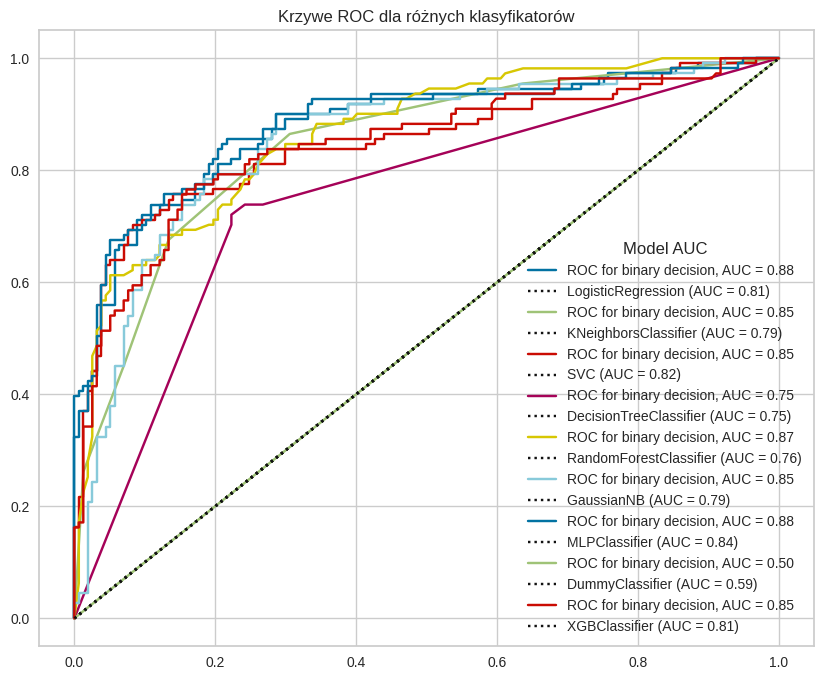

In [23]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

for model in models:
    visualizer = ROCAUC(model, classes=['Not Survived', 'Survived'], micro=False, macro=False, per_class=False, ax=ax)
    name = f"{model.__class__.__name__}"

    # Trening modelu na danych treningowych
    visualizer.fit(X_train, y_train)

    # Ocena modelu na danych testowych i pobranie wartości AUC
    auc_score = visualizer.score(X_test, y_test)

    # Ustawienie etykiety z wartością AUC
    visualizer.ax.lines[-1].set_label(f'{name} (AUC = {auc_score:.2f})')

ax.legend(loc='lower right', title='Model AUC')
ax.set_title('Krzywe ROC dla różnych klasyfikatorów')
plt.show()

In [24]:
rf = ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [25]:
rf.score(X_test, y_test)

0.7611940298507462

In [26]:
precision_score(y_test, rf.predict(X_test))

0.719626168224299

In [27]:
import pandas as pd

# Pobranie ważności cech z wytrenowanego modelu RandomForestClassifier
feature_importances = rf.feature_importances_

# Pobranie nazw cech
feature_names = X_train.columns

# Utworzenie DataFrame dla lepszej wizualizacji
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Posortowanie cech według ważności
importances_df = importances_df.sort_values(by='Importance', ascending=False)

print("Ważność cech w modelu Random Forest:")
print(importances_df)

Ważność cech w modelu Random Forest:
      Feature  Importance
1         age    0.266659
4        fare    0.258758
6    sex_male    0.255153
0      pclass    0.087248
2       sibsp    0.044914
3       parch    0.031488
8  embarked_S    0.028059
5       alone    0.016638
7  embarked_Q    0.011083


In [28]:
print(f"Suma ważności cech: {feature_importances.sum():.4f}")

Suma ważności cech: 1.0000


In [29]:
# Naprawa błędu ImportError: niezgodność joblib i loky.
# Zainstaluj joblib w wersji 1.1.0, a następnie ZRESTARTUJ ŚRODOWISKO WYKONAWCZE (Runtime -> Restart runtime).
# Po restarcie uruchom ponownie tę komórkę.
# !pip install joblib==1.1.0


rf4 = ensemble.RandomForestClassifier()
params = {"max_features": [0.4,0.6],
          "n_estimators": [15, 17,20],
          "min_samples_leaf" : [1, 2,4],
          "random_state": [30,42]}
cv = model_selection.GridSearchCV(rf4, params, n_jobs=-1, cv=5, verbose=1).fit(X_train, y_train)
print(cv.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'max_features': 0.4, 'min_samples_leaf': 4, 'n_estimators': 15, 'random_state': 42}


In [40]:
rf5 = ensemble.RandomForestClassifier(**{"max_features":"sqrt", "min_samples_leaf": 0.1, "n_estimators": 200, "random_state":42})
rf5.fit(X_train, y_train)
rf5.score(X_test, y_test)

0.75

In [31]:
rf5 = ensemble.RandomForestClassifier(**{"max_features":0.4, "min_samples_leaf": 4, "n_estimators": 15, "random_state":42})
rf5.fit(X_train, y_train)
rf5.score(X_test, y_test)

0.8022388059701493

In [41]:
y_pred = rf5.predict(X_test)
confusion_matrix(y_test, y_pred)


array([[141,  16],
       [ 51,  60]])

/usr/local/lib/python3.13/dist-packages/yellowbrick/classifier/base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(


[Text(0.5, 1.0, 'tabica pomylek klasfikatora lasu losowego'),
 Text(0.5, 0, 'klasa porgnozowana'),
 Text(0, 0.5, 'klasa rzeczywista')]

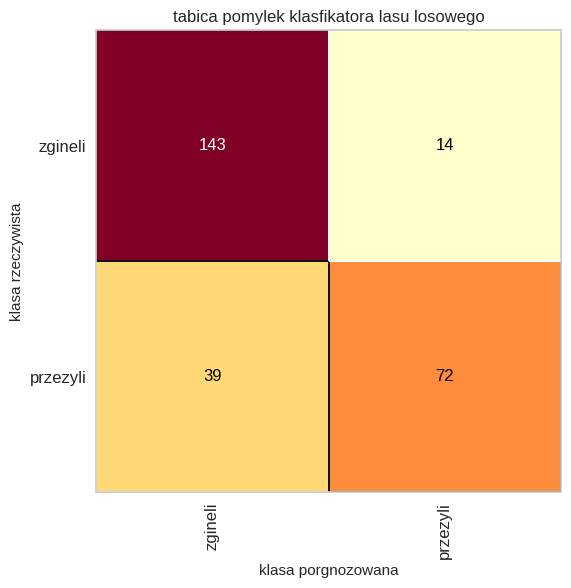

In [38]:
mapping = {0: "zgineli", 1: "przezyli"}
fig, ax = plt.subplots(figsize=(6, 6))
cm_viz = ConfusionMatrix(rf5, classes=["zgineli", 'przezyli'], label_encoder = mapping)
cm_viz.score(X_test, y_test)
cm_viz.ax.set(title='tabica pomylek klasfikatora lasu losowego', xlabel = "klasa porgnozowana", ylabel="klasa rzeczywista")


<Axes: >

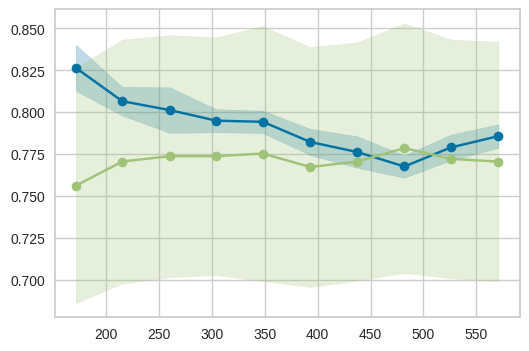

In [44]:
import numpy as np
fig, ax = plt.subplots(figsize=(6, 4))
cv = StratifiedKFold(12)
sizes = np.linspace(0.3, 1.0, 10)
lc_viz = LearningCurve(rf5, cv=cv, scoring='accuracy', train_sizes=sizes, ax=ax)
lc_viz.fit(X_train, y_train)
lc_viz.ax

In [48]:
import pickle
pic = pickle.dumps(rf5)
rf6 = pickle.loads(pic)
y_pred = rf6.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[141,  16],
       [ 51,  60]])